### This notebook compute "VCA4. Level of progress of the Climate Change Mitigation and Adaptation Plan " indicator for the 27 basins of IKI Project

Spanish: Nivel de avance del Plan de Mitigación y Adaptación al Cambio Climático

**Created:** 10/10/2025 by Serena Gilson (sgilson@rti.org)  

**Project #:** 0219481  

**Last modified:** 1/12/2026 by Sophia (sbakar@rti.org)

**Status:** Complete and loaded in SQLite database for the baseline and first future scenario. 

**QA Status:** reviewed by  

**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad

 
**Inputs:**   Shapefile of COMIDs and districts, Excel of PMACC status for each EPS from Isabel Málaga del Ministerio de Vivienda, Construcción y Saneamiento 

**Outputs:** 
 
**Assumptions:** For now, given we don't have additional details, we are just giving a 0 or 1 depending on whether ot not they have an EPS at all. Any COMID that is touching the district with the EPS will get the PMACC association 

    1. I associated the attribute of if the EPS has PMACC or not (from AI2a_Metodologia\Indicadores\Vulnerabilidad\EPS_PMACC.xlsx) to the Demandas_EPS shapefile (Grupos_Modelacion\GIS_WaterALLOC_General\Demandas_EPS.shp)
    2. I assigned a 1 if the EPS has a PMACC, 0 if it does not. 
    3. I read in the district shapefile, and associated the district each EPS is located in.
    4. For each COMID, if it intersected with a district that has an EPS located within it, I assigned it the 'max' PMACC score (i.e. if one COMID intersected with 5 districts, and one of the districts had a PMACC, the COMID got a 1)
The guide says if a district (or in our case a COMID) does not have an EPS, assign NaN and do not include in the vulnerability equation.

**Future work:** 
 
**Notes:** 

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
# set up user and database path
#user = 'jmayo'
#user= 'cpickering'
#user = 'sgilson'
#user = 'nreynolds'
user = 'sbakar'
#db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'
db_path = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db"

In [3]:
# set up indicator ID and get scenarios from database
IndID= 504 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: only baseline and first future
scenario_ids = scenarios_df.loc[
    scenarios_df['ScnID'].isin([1, 2]), 'ScnID'
].tolist()

# for all scenarios:
# scenario_ids = scenarios_df['ScnID'].tolist()

In [4]:
# define filepaths for input data
#subbasins_shapefile = fr"C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp"
subbasins_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"

# PMACC = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad\EPS_PMACC.xlsx'
PMACC = fr'C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad\EPS_PMACC.xlsx'

#demandas_EPS = fr"C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Demandas_EPS.shp"
demandas_EPS = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Demandas_EPS.shp"

# distritos = fr"C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\GIS\3_HIDROLOGIA_HYDROGRAPHY\Datos_ANA\BD_ANA.gdb"
distritos = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\GIS\3_HIDROLOGIA_HYDROGRAPHY\Datos_ANA\BD_ANA.gdb"


In [5]:
# read in input data
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')
demandas_EPS = gpd.read_file(demandas_EPS).to_crs('EPSG:32718')
distritos_gdf = gpd.read_file(distritos, layer='Distrito').to_crs('EPSG:32718')
pmacc_df = pd.read_excel(PMACC, sheet_name='Analisis')

In [6]:
# format the PMACC data
#make the second row the header 
pmacc_df.columns = pmacc_df.iloc[1]
pmacc_df = pmacc_df[2:]

#rename column for easier access
pmacc_df = pmacc_df.rename(columns={'PMACC en formulación o finalizado, ha solicitado AT al MVCS': 'PMACC_Status'})

#trim down df to just EPS-Nombre, Cuenca (datos PACA), Localidades, PMACC_Status
pmacc_trimmed = pmacc_df[['EPS-Nombre', 'Cuenca (datos PACA)', 'Localidades', 'PMACC_Status']]

#remove rows where PMACC_Status is NaN
pmacc_trimmed = pmacc_trimmed.dropna(subset=['PMACC_Status'])

#add PMACC status to demandas_EPS shapefile
demandas_EPS = demandas_EPS.merge(pmacc_trimmed, left_on='EPS-Nombre', right_on='EPS-Nombre', how='left')


In [7]:
# assign PMACC_Score based on PMACC_Status (SI= 1, NO=0, nan=NAN )
def pmacc_score(status):
    if status == 'SI':
        return 1
    elif status == 'NO':
        return 0
    else:
        return np.nan
    
demandas_EPS['PMACC_Score'] = demandas_EPS['PMACC_Status'].apply(pmacc_score)

#maintain only the columns EPS-Nombre, PMACC_Status, geometry
demandas_EPS_clean = demandas_EPS[['EPS-Nombre', 'PMACC_Score', 'geometry']]

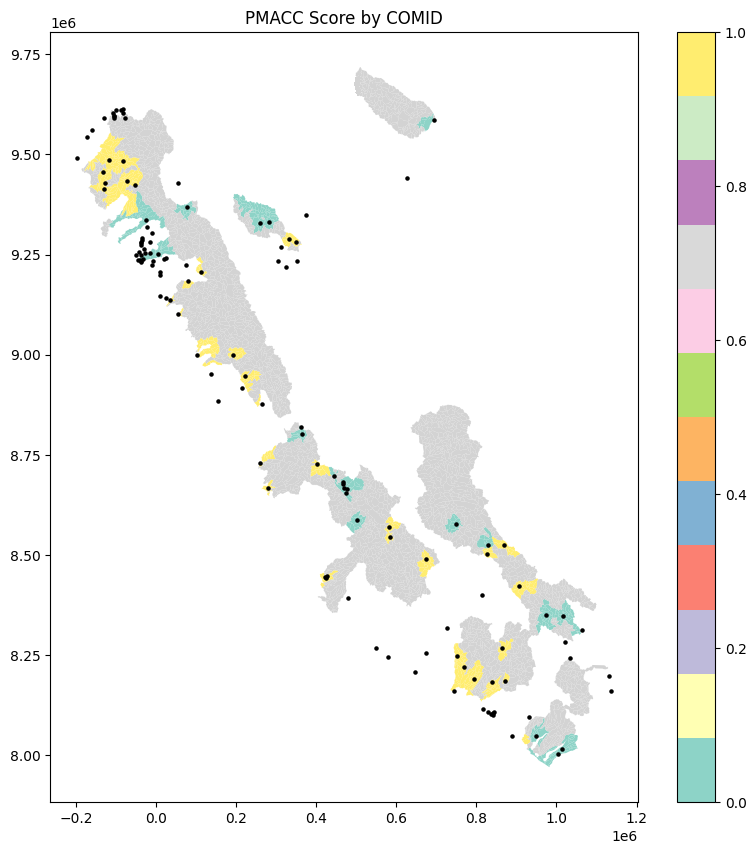

In [9]:
#SPATIAL JOINS AND ASSIGNING PMACC SCORES TO SUBBASINS

#spatially join the EPS-Nombre, PMACC_Status to the district file
distritos_pmacc = gpd.sjoin(distritos_gdf, demandas_EPS_clean, how='left', predicate='intersects')

#if the COMID from subbasins_gdf intersects with the district, assign the PMACC status to the subbasin
subbasins_pmacc = gpd.sjoin(subbasins_gdf, distritos_pmacc[['ID_DIST', 'PMACC_Score', 'geometry']], how='left', predicate='intersects')
subbasins_pmacc = subbasins_pmacc[['COMID', 'ID_DIST', 'PMACC_Score', 'geometry']]

#clean up results so if a subbasin is associated with more than one district, it keeps the maximum PMACC_Score
subbasins_pmacc = subbasins_pmacc.sort_values(by='PMACC_Score', ascending=False).drop_duplicates(subset=['COMID'])

#PLOT RESULTS

#visually plot the results
fig, ax = plt.subplots(figsize=(10,10))
subbasins_pmacc.plot(column='PMACC_Score', ax=ax, legend=True, cmap='Set3', missing_kwds={'color': 'lightgrey', 'label': 'No data'})
#also plot EPS point locations from demandas_EPS_clean
demandas_EPS_clean.plot(ax=ax, color='black', markersize=5)
plt.title('PMACC Score by COMID')
plt.show()

PMACC Score for COMID 320254600: 1.0


C:\Users\sbakar\AppData\Local\Temp\ipykernel_107976\2096213641.py:44: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='upper right')


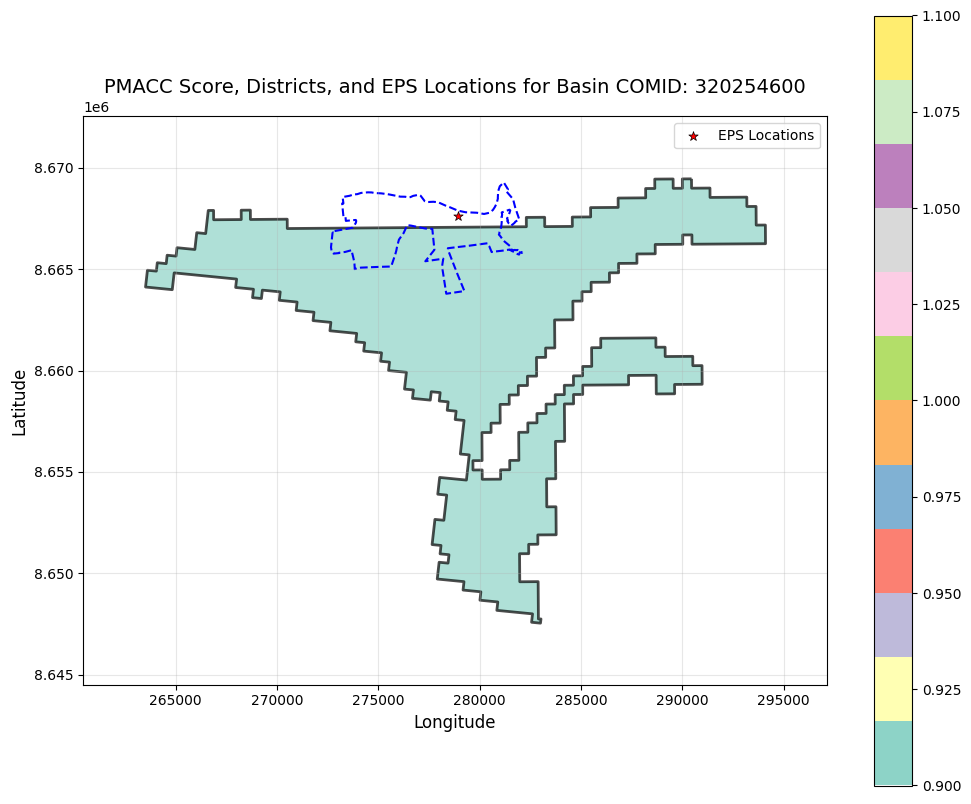

In [10]:
#VISUAL QC OF A SPECIFIC BASIN

# Specify the COMID to plot
target_comid = 320254600

# Filter the subbasin for the target COMID
target_basin = subbasins_pmacc[subbasins_pmacc['COMID'] == target_comid]

#print PMACC score for the target basin
print(f"PMACC Score for COMID {target_comid}: {target_basin['PMACC_Score'].values[0]}")

# Get the district ID(s) for this basin
target_districts = target_basin['ID_DIST'].unique()

# Filter districts that intersect with the target basin
districts_in_basin = distritos_gdf[distritos_gdf['ID_DIST'].isin(target_districts)]

# Initialize a plot
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the target subbasin with PMACC score
target_basin.plot(ax=ax, column='PMACC_Score', cmap='Set3', edgecolor='black', 
                  linewidth=2, alpha=0.7, legend=True,
                  missing_kwds={'color': 'lightgrey', 'label': 'No data'})

# Plot district boundaries
districts_in_basin.plot(ax=ax, facecolor='none', edgecolor='blue', 
                        linewidth=1.5, linestyle='--', label='District Boundary')

# Get the bounds of the target basin to set the extent
bounds = target_basin.total_bounds
buffer = 0.1 * max(bounds[2] - bounds[0], bounds[3] - bounds[1])  # 10% buffer
ax.set_xlim(bounds[0] - buffer, bounds[2] + buffer)
ax.set_ylim(bounds[1] - buffer, bounds[3] + buffer)

# Plot EPS points within or near the target basin
demandas_EPS_clean.plot(ax=ax, color='red', markersize=50, marker='*', 
                        edgecolor='black', linewidth=0.5, label='EPS Locations')

# Add title, legend, and labels
plt.title(f'PMACC Score, Districts, and EPS Locations for Basin COMID: {target_comid}', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend(loc='upper right')

# Add grid for better readability
ax.grid(True, alpha=0.3)

# Show the plot
plt.show()

SQLITE INSERT 

In [11]:
# insert results into the database 
insert_data= subbasins_pmacc 
value_column= 'PMACC_Score' #column with calculated values to be inserted into the database

# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Prepare list of rows to insert
rows_to_insert = []

for scn_id in scenario_ids:
    for _, row in insert_data.iterrows():
        comid = row['COMID']
        value = row[value_column]
        rows_to_insert.append((scn_id, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [12]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    subbasins_pmacc['PMACC_Score']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted (by scenario) ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 504  Min: 0, Max: 1

=== Values to be inserted (by scenario) ===
   index  PMACC_Score
0    min          0.0
1    max          1.0
2  count        662.0
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [13]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()